In [ ]:
# Montage Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -q install SimpleITK torch torchvision pandas scikit-learn tqdm

import os
import numpy as np
import pandas as pd
import SimpleITK as sitk
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 14.1 MB/s eta 0:00:00


In [ ]:
# --- Tes chemins ---
ROOT = "/content/drive/MyDrive/spin_mri"
IMG_DIR  = os.path.join(ROOT, "images")
MSK_DIR  = os.path.join(ROOT, "masks")
OVERVIEW_CSV = os.path.join(ROOT, "overview.csv")
GRADINGS_CSV = os.path.join(ROOT, "radiological_gradings.csv")

assert os.path.exists(OVERVIEW_CSV), "overview.csv introuvable"
assert os.path.exists(GRADINGS_CSV), "radiological_gradings.csv introuvable"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cpu'

In [ ]:
#Utils (I/O, normalisation, bbox, crop)
def read_mha(path: str) -> np.ndarray:
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img)  # (Z,Y,X)
    return arr.astype(np.float32)

def zscore(x: np.ndarray, eps=1e-6) -> np.ndarray:
    return (x - x.mean()) / (x.std() + eps)

def bbox2d(mask2d: np.ndarray):
    ys, xs = np.where(mask2d > 0)
    if len(xs) == 0:
        return None
    return int(ys.min()), int(xs.min()), int(ys.max()), int(xs.max())

def center_pad_crop2d(img: np.ndarray, out_size: int) -> np.ndarray:
    h, w = img.shape
    out = np.zeros((out_size, out_size), dtype=img.dtype)

    y0 = max(0, (h - out_size)//2)
    x0 = max(0, (w - out_size)//2)
    y1 = min(h, y0 + out_size)
    x1 = min(w, x0 + out_size)

    crop = img[y0:y1, x0:x1]
    oy0 = (out_size - crop.shape[0])//2
    ox0 = (out_size - crop.shape[1])//2
    out[oy0:oy0+crop.shape[0], ox0:ox0+crop.shape[1]] = crop
    return out

def crop_with_margin(img2d: np.ndarray, mask2d: np.ndarray, roi_size=128, margin=12):
    bb = bbox2d(mask2d)
    if bb is None:
        return None
    y0,x0,y1,x1 = bb
    y0 = max(0, y0 - margin)
    x0 = max(0, x0 - margin)
    y1 = min(mask2d.shape[0]-1, y1 + margin)
    x1 = min(mask2d.shape[1]-1, x1 + margin)
    crop = img2d[y0:y1+1, x0:x1+1]
    return center_pad_crop2d(crop, roi_size)


In [ ]:
#Construire la table “disque-niveau” + label binaire
import os, glob
import pandas as pd
import numpy as np

IMG_DIR  = "/content/drive/MyDrive/spin_mri/images"
MSK_DIR  = "/content/drive/MyDrive/spin_mri/masks"
OVERVIEW_CSV = "/content/drive/MyDrive/spin_mri/overview.csv"
GRADINGS_CSV = "/content/drive/MyDrive/spin_mri/radiological_gradings.csv"

overview = pd.read_csv(OVERVIEW_CSV)
gradings = pd.read_csv(GRADINGS_CSV)

# --- 1) indexer tous les fichiers .mha réellement présents ---
img_files = glob.glob(os.path.join(IMG_DIR, "*.mha"))
msk_files = glob.glob(os.path.join(MSK_DIR, "*.mha"))

img_map = {os.path.splitext(os.path.basename(p))[0]: p for p in img_files}   # "1_t2" -> ".../1_t2.mha"
msk_map = {os.path.splitext(os.path.basename(p))[0]: p for p in msk_files}

print("Nb images trouvées:", len(img_map), "Nb masques trouvés:", len(msk_map))

# --- 2) garder T2 (DD = T2) ---
overview_t2 = overview[overview["new_file_name"].astype(str).str.contains("_t2", case=False, na=False)].copy()

# IMPORTANT: dans le csv, new_file_name est un "stem" (ex: 1_t2)
overview_t2["stem"] = overview_t2["new_file_name"].astype(str)

# patient id = partie avant "_" (ex: "1" dans "1_t2")
overview_t2["Patient"] = overview_t2["stem"].str.split("_").str[0].astype(str)

# --- 3) préparer gradings + label binaire à partir de Pfirrmann ---
g = gradings.copy()
g["Patient"] = g["Patient"].astype(str)
g["Pfirrman grade"] = pd.to_numeric(g["Pfirrman grade"], errors="coerce")
g = g.dropna(subset=["Pfirrman grade", "IVD label"]).copy()

# binaire: 0 si I–II, 1 si III–V
g["label_bin"] = (g["Pfirrman grade"] >= 3).astype(int)
g = g.rename(columns={"IVD label": "ivd_label"})
g["ivd_label"] = pd.to_numeric(g["ivd_label"], errors="coerce").astype(int)

# --- 4) associer chaque Patient -> stem T2 via overview, puis résoudre paths via img_map/msk_map ---
# (si un patient a plusieurs T2, on prend le premier; tu peux raffiner si besoin)
pat_to_stem = overview_t2.groupby("Patient")["stem"].first().to_dict()

g["stem"] = g["Patient"].map(pat_to_stem)
g = g.dropna(subset=["stem"]).copy()

g["image_path"] = g["stem"].map(img_map)
g["mask_path"]  = g["stem"].map(msk_map)

g["img_exists"] = g["image_path"].apply(lambda x: isinstance(x, str) and os.path.exists(x))
g["msk_exists"] = g["mask_path"].apply(lambda x: isinstance(x, str) and os.path.exists(x))

print("Images manquantes:", (~g["img_exists"]).sum(), "Masques manquants:", (~g["msk_exists"]).sum())

# garder uniquement les lignes OK
g = g[g["img_exists"] & g["msk_exists"]].reset_index(drop=True)

g.head()


Nb images trouvées: 447 Nb masques trouvés: 450
Images manquantes: 0 Masques manquants: 0


,Patient,ivd_label,Modic,UP endplate,LOW endplate,Spondylolisthesis,Disc herniation,Disc narrowing,Disc bulging,Pfirrman grade,label_bin,stem,image_path,mask_path,img_exists,msk_exists
0,1,1,0,0,0,0,0,1,1,3,1,1_t2,/content/drive/MyDrive/spin_mri/images/1_t2.mha,/content/drive/MyDrive/spin_mri/masks/1_t2.mha,True,True
1,1,2,0,0,0,0,0,0,1,3,1,1_t2,/content/drive/MyDrive/spin_mri/images/1_t2.mha,/content/drive/MyDrive/spin_mri/masks/1_t2.mha,True,True
2,1,3,0,0,0,0,0,1,1,3,1,1_t2,/content/drive/MyDrive/spin_mri/images/1_t2.mha,/content/drive/MyDrive/spin_mri/masks/1_t2.mha,True,True
3,1,4,0,0,0,0,0,1,1,4,1,1_t2,/content/drive/MyDrive/spin_mri/images/1_t2.mha,/content/drive/MyDrive/spin_mri/masks/1_t2.mha,True,True
4,1,5,0,0,0,0,0,1,0,4,1,1_t2,/content/drive/MyDrive/spin_mri/images/1_t2.mha,/content/drive/MyDrive/spin_mri/masks/1_t2.mha,True,True


In [ ]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

def read_mha(path):
    img = sitk.ReadImage(path)
    return sitk.GetArrayFromImage(img).astype(np.float32)

def compute_snr(volume, bg_thresh=5):
    """
    volume : image 3D (Z, Y, X)
    bg_thresh : seuil pour approximer le fond (air)
    """
    # Signal = moyenne des intensités non nulles
    signal = volume[volume > bg_thresh].mean()

    # Bruit = écart-type du fond
    background = volume[volume <= bg_thresh]
    noise = background.std()

    snr = signal / (noise + 1e-8)
    return signal, noise, snr

# Exemple d'utilisation
img_path = "/content/drive/MyDrive/spin_mri/images/1_t2.mha"
vol = read_mha(img_path)

signal, noise, snr = compute_snr(vol)

print(f"Signal moyen      : {signal:.2f}")
print(f"Bruit estimé      : {noise:.2f}")
print(f"Rapport SNR       : {snr:.2f}")


Signal moyen      : 1820.43
Bruit estimé      : 139.95
Rapport SNR       : 13.01


In [ ]:
sorted(g["ivd_label"].unique())


[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9)]

In [ ]:
#4) Keep lumbar discs only (ivd_label 1..5)
DISC_LEVELS = [1,2,3,4,5]
g_lumbar = g[g["ivd_label"].isin(DISC_LEVELS)].reset_index(drop=True)

print("Avant:", len(g), "Après lombaire 1..5:", len(g_lumbar))
print("ivd_label uniques:", sorted(g_lumbar["ivd_label"].unique()))
print("labels bin:", g_lumbar["label_bin"].value_counts().to_dict())


Avant: 1476 Après lombaire 1..5: 1060
ivd_label uniques: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
labels bin: {1: 715, 0: 345}


In [ ]:
#5) Split train/val by PATIENT
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(splitter.split(g_lumbar, groups=g_lumbar["Patient"]))

df_train = g_lumbar.iloc[tr_idx].reset_index(drop=True)
df_val   = g_lumbar.iloc[va_idx].reset_index(drop=True)

print("Train discs:", len(df_train), "Val discs:", len(df_val))
print("Train patients:", df_train["Patient"].nunique(), "Val patients:", df_val["Patient"].nunique())
print("Train label_bin:", df_train["label_bin"].value_counts().to_dict())
print("Val   label_bin:", df_val["label_bin"].value_counts().to_dict())


Train discs: 845 Val discs: 215
Train patients: 169 Val patients: 43
Train label_bin: {1: 569, 0: 276}
Val   label_bin: {1: 146, 0: 69}


In [ ]:
#Segmentation dataset (target = mask in {1..5})
DISC_LABELS = set([1,2,3,4,5])

class SegSliceDataset(Dataset):
    def __init__(self, df, img_size=256, mode="max_disc"):
        """
        mode:
        - 'max_disc' : slice la plus informative (RECOMMANDÉ)
        - 'random'   : slice aléatoire
        """
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        vol = read_mha(row["image_path"]).astype(np.float32)  # (Z,Y,X)
        msk = read_mha(row["mask_path"]).astype(np.int32)

        # masque disque uniquement
        msk_disc = np.isin(msk, list(DISC_LABELS)).astype(np.float32)

        # CHOIX DE LA SLICE
        if self.mode == "max_disc":
            areas = msk_disc.reshape(msk_disc.shape[0], -1).sum(axis=1)
            if areas.max() > 0:
                z = int(np.argmax(areas))
            else:
                z = vol.shape[0] // 2  # fallback sécurité
        else:
            z = np.random.randint(0, vol.shape[0])

        # extraction slice
        img2d = zscore(vol[z])
        m2d   = msk_disc[z]

        # resize / pad
        img2d = center_pad_crop2d(img2d, self.img_size)
        m2d   = center_pad_crop2d(m2d, self.img_size)

        x = torch.from_numpy(img2d[None, ...])  # (1,H,W)
        y = torch.from_numpy(m2d[None, ...])    # (1,H,W)
        return x, y


In [ ]:
# === Définition du modèle U-Net 2D ===

import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(base, base*2)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base*4, base*8)

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = DoubleConv(base*8, base*4)

        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = DoubleConv(base*4, base*2)

        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = DoubleConv(base*2, base)

        self.outc = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.outc(d1)


In [ ]:
# === Train segmentation (slice la plus informative) ===

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

SEG_IMG_SIZE = 256
SEG_EPOCHS = 20
SEG_BS = 8
SEG_LR = 1e-3

SEG_CKPT = os.path.join(ROOT, "seg_unet2d_disc_maxslice.pt")

#  datasets: slice la plus informative
ds_seg_tr = SegSliceDataset(df_train, img_size=SEG_IMG_SIZE, mode="max_disc")
ds_seg_va = SegSliceDataset(df_val,   img_size=SEG_IMG_SIZE, mode="max_disc")

#  loaders (0 workers = évite erreurs Colab + plus stable)
dl_seg_tr = DataLoader(ds_seg_tr, batch_size=SEG_BS, shuffle=True,  num_workers=0)
dl_seg_va = DataLoader(ds_seg_va, batch_size=SEG_BS, shuffle=False, num_workers=0)

seg_model = UNet2D().to(DEVICE)
opt = torch.optim.AdamW(seg_model.parameters(), lr=SEG_LR)

def dice_batch_from_logits(logits, targets, thr=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    num = 2 * (preds * targets).sum(dim=(2,3)) + eps
    den = (preds + targets).sum(dim=(2,3)) + eps
    return (num / den).mean().item()

def dice_loss(logits, targets, eps=1e-6):
    # Calculate Dice score
    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    union = (probs + targets).sum(dim=(1, 2, 3))
    dice_score = (2. * intersection + eps) / (union + eps)
    # Dice loss is typically 1 - Dice score
    return (1 - dice_score).mean()

best = 1e9

for ep in range(SEG_EPOCHS):
    # --- train ---
    seg_model.train()
    tr_losses = []
    for x,y in tqdm(dl_seg_tr, desc=f"SEG(max) {ep+1}/{SEG_EPOCHS} train"):
        x,y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad(set_to_none=True)

        logits = seg_model(x)
        loss = F.binary_cross_entropy_with_logits(logits, y) + dice_loss(logits, y)

        loss.backward()
        opt.step()
        tr_losses.append(loss.item())

    # --- val ---
    seg_model.eval()
    va_losses = []
    va_dices = []
    with torch.no_grad():
        for x,y in tqdm(dl_seg_va, desc=f"SEG(max) {ep+1}/{SEG_EPOCHS} val"):
            x,y = x.to(DEVICE), y.to(DEVICE)
            logits = seg_model(x)
            loss = F.binary_cross_entropy_with_logits(logits, y) + dice_loss(logits, y)
            va_losses.append(loss.item())
            va_dices.append(dice_batch_from_logits(logits, y))

    tr_m = float(np.mean(tr_losses))
    va_m = float(np.mean(va_losses))
    va_d = float(np.mean(va_dices))

    print(f"Epoch {ep+1}: train_loss={tr_m:.4f} | val_loss={va_m:.4f} | val_dice={va_d:.4f}")

    if va_m < best:
        best = va_m
        torch.save(seg_model.state_dict(), SEG_CKPT)
        print("✅ Saved best:", SEG_CKPT)


SEG(max) 1/20 val: 100%|██████████| 27/27 [03:21<00:00,  7.45s/it]


Epoch 1: train_loss=1.3714 | val_loss=1.0973 | val_dice=0.5144
✅ Saved best: /content/drive/MyDrive/spin_mri/seg_unet2d_disc_maxslice.pt


SEG(max) 2/20 val: 100%|██████████| 27/27 [02:19<00:00,  5.15s/it]


Epoch 2: train_loss=0.9257 | val_loss=0.7448 | val_dice=0.7258
✅ Saved best: /content/drive/MyDrive/spin_mri/seg_unet2d_disc_maxslice.pt


SEG(max) 3/20 val: 100%|██████████| 27/27 [02:19<00:00,  5.16s/it]


...

Epoch 18: train_loss=0.0778 | val_loss=0.1895 | val_dice=0.8551
✅ Saved best: /content/drive/MyDrive/spin_mri/seg_unet2d_disc_maxslice.pt


SEG(max) 19/20 val: 100%|██████████| 27/27 [02:21<00:00,  5.22s/it]


Epoch 19: train_loss=0.0570 | val_loss=0.2012 | val_dice=0.8450


SEG(max) 20/20 val: 100%|██████████| 27/27 [02:22<00:00,  5.27s/it]

Epoch 20: train_loss=0.0523 | val_loss=0.1848 | val_dice=0.8573
✅ Saved best: /content/drive/MyDrive/spin_mri/seg_unet2d_disc_maxslice.pt


Slice choisie: 137


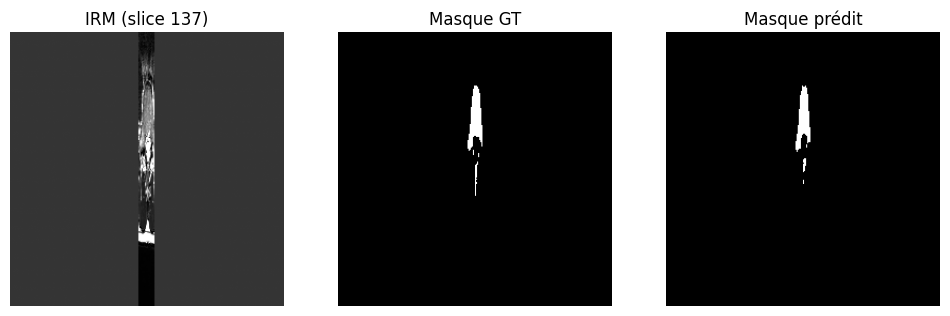

Dice (image spécifique): 0.916895


In [ ]:
#teste de segmentation sur une image:
img_path = "/content/drive/MyDrive/spin_mri/images/12_t2.mha"
msk_path = "/content/drive/MyDrive/spin_mri/masks/12_t2.mha"
import matplotlib.pyplot as plt

# charger image et masque
vol = read_mha(img_path).astype(np.float32)   # (Z,Y,X)
msk = read_mha(msk_path).astype(np.int32)

# garder seulement les disques (labels 1..5)
msk_disc = np.isin(msk, [1,2,3,4,5]).astype(np.float32)

# charger le meilleur modèle
seg_best = UNet2D().to(DEVICE)
seg_best.load_state_dict(torch.load(SEG_CKPT, map_location=DEVICE))
seg_best.eval()
z = vol.shape[0] // 2
areas = msk_disc.reshape(msk_disc.shape[0], -1).sum(axis=1)
z = int(np.argmax(areas))
print("Slice choisie:", z)
img2d = zscore(vol[z])
img2d = center_pad_crop2d(img2d, 256)

x = torch.from_numpy(img2d[None,None,...]).to(DEVICE)

with torch.no_grad():
    logits = seg_best(x)
    pred = torch.sigmoid(logits)[0,0].cpu().numpy()
gt = center_pad_crop2d(msk_disc[z], 256)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("IRM (slice {})".format(z))
plt.imshow(img2d, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Masque GT")
plt.imshow(gt, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Masque prédit")
plt.imshow(pred > 0.5, cmap="gray")
plt.axis("off")

plt.show()
def dice_single(pred, gt, eps=1e-6):
    pred = (pred > 0.5).astype(np.float32)
    num = 2 * (pred * gt).sum() + eps
    den = pred.sum() + gt.sum() + eps
    return num / den

dice_img = dice_single(pred, gt)
print("Dice (image spécifique):", dice_img)


In [ ]:
# Classification
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# --- util bbox + crop  ---
def bbox2d(mask2d: np.ndarray):
    ys, xs = np.where(mask2d > 0)
    if len(xs) == 0:
        return None
    return int(ys.min()), int(xs.min()), int(ys.max()), int(xs.max())

def crop_with_margin(img2d: np.ndarray, mask2d: np.ndarray, roi_size=128, margin=12):
    bb = bbox2d(mask2d)
    if bb is None:
        return None
    y0,x0,y1,x1 = bb
    y0 = max(0, y0 - margin); x0 = max(0, x0 - margin)
    y1 = min(mask2d.shape[0]-1, y1 + margin); x1 = min(mask2d.shape[1]-1, x1 + margin)
    crop = img2d[y0:y1+1, x0:x1+1]
    return center_pad_crop2d(crop, roi_size)

# --- ROI stack extraction ---
def extract_roi_stack(vol, msk_vol, ivd_label, k=5, roi_size=128, margin=12):
    # disque exact
    disc = (msk_vol == ivd_label).astype(np.uint8)

    # fallback si jamais label absent: disques lombaires global (1..5)
    if disc.sum() == 0:
        disc = np.isin(msk_vol, [1,2,3,4,5]).astype(np.uint8)

    areas = disc.reshape(disc.shape[0], -1).sum(axis=1)
    if areas.max() == 0:
        return None

    z_best = int(np.argmax(areas))
    half = k//2
    zs = [min(max(z_best + i, 0), vol.shape[0]-1) for i in range(-half, half+1)]

    stack = []
    for z in zs:
        roi = crop_with_margin(vol[z], disc[z], roi_size=roi_size, margin=margin)
        if roi is None:
            return None
        stack.append(roi)
    return np.stack(stack, axis=0)  # (k,H,W)

# --- Dataset classification ---
class DiscClsDataset(Dataset):
    def __init__(self, df, k=5, roi_size=128, margin=12):
        self.df = df.reset_index(drop=True)
        self.k = k
        self.roi_size = roi_size
        self.margin = margin

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        vol = read_mha(row["image_path"]).astype(np.float32)
        vol = zscore(vol)
        msk = read_mha(row["mask_path"]).astype(np.int32)

        ivd_label = int(row["ivd_label"])
        y = float(row["label_bin"])

        roi_stack = extract_roi_stack(vol, msk, ivd_label, k=self.k, roi_size=self.roi_size, margin=self.margin)
        if roi_stack is None:
            midz = vol.shape[0]//2
            half = self.k//2
            zs = [min(max(midz+i, 0), vol.shape[0]-1) for i in range(-half, half+1)]
            roi_stack = np.stack([center_pad_crop2d(vol[z], self.roi_size) for z in zs], axis=0)

        x = torch.from_numpy(roi_stack)           # (k,H,W)
        y = torch.tensor([y], dtype=torch.float32)
        return x, y

# --- dataloaders (mets num_workers=0 si CPU / éviter bugs scope) ---
K = 5
ROI_SIZE = 128
MARGIN = 12

NUM_WORKERS = 0  # <- IMPORTANT surtout si tu es sur CPU / runtime instable
dl_tr = DataLoader(DiscClsDataset(df_train, K, ROI_SIZE, MARGIN),
                   batch_size=16, shuffle=True, num_workers=NUM_WORKERS)
dl_va = DataLoader(DiscClsDataset(df_val, K, ROI_SIZE, MARGIN),
                   batch_size=16, shuffle=False, num_workers=NUM_WORKERS)

print("OK: extract_roi_stack défini, loaders prêts.")


OK: extract_roi_stack défini, loaders prêts.


In [ ]:
# === Modèle de classification : ResNet18 2.5D ===

import torch
import torch.nn as nn
from torchvision.models import resnet18

def make_resnet18_kch(k: int):
    """
    ResNet18 adapté pour une entrée 2.5D (k slices empilées comme canaux)
    Sortie: 1 logit (classification binaire)
    """
    model = resnet18(weights=None)

    # remplacer la première couche pour accepter k canaux
    model.conv1 = nn.Conv2d(
        in_channels=k,
        out_channels=64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )

    # remplacer la couche finale pour binaire
    model.fc = nn.Linear(model.fc.in_features, 1)

    return model


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score

# --- Dataset ---
K = 5
ROI_SIZE = 128
MARGIN = 12

ds_tr = DiscClsDataset(df_train, k=K, roi_size=ROI_SIZE, margin=MARGIN)
ds_va = DiscClsDataset(df_val,   k=K, roi_size=ROI_SIZE, margin=MARGIN)

# --- WeightedRandomSampler (équilibre 0 et 1) ---
y_train = df_train["label_bin"].values.astype(int)
class_counts = np.bincount(y_train)                 # [n0, n1]
class_weights = 1.0 / class_counts                  # poids inverse
sample_weights = class_weights[y_train]             # poids par sample

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True
)

dl_tr = DataLoader(ds_tr, batch_size=16, sampler=sampler, num_workers=0)
dl_va = DataLoader(ds_va, batch_size=16, shuffle=False, num_workers=0)

print("Train counts:", dict(zip([0,1], class_counts)))
print("Sampler weights:", class_weights)

# --- Modèle ---
cls_model = make_resnet18_kch(K).to(DEVICE)
opt = torch.optim.AdamW(cls_model.parameters(), lr=1e-4)

# --- Loss ---
criterion = nn.BCEWithLogitsLoss()

def eval_cls(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for x,y in loader:
            x = x.to(DEVICE)
            logits = model(x).squeeze(1).cpu().numpy()
            prob = 1/(1+np.exp(-logits))
            ys.extend(y.squeeze(1).numpy().tolist())
            ps.extend(prob.tolist())

    ys = np.array(ys).astype(int)
    ps = np.array(ps)

    pred = (ps >= 0.5).astype(int)
    acc  = accuracy_score(ys, pred)
    bacc = balanced_accuracy_score(ys, pred)
    f1   = f1_score(ys, pred)
    auc  = roc_auc_score(ys, ps) if len(np.unique(ys)) > 1 else float("nan")
    return acc, bacc, f1, auc

# --- Train loop ---
CLS_EPOCHS = 15
CLS_CKPT = "/content/drive/MyDrive/spin_mri/cls_resnet25d_bin_sampler.pt"
best_auc = -1

for ep in range(CLS_EPOCHS):
    cls_model.train()
    losses = []

    for x,y in dl_tr:
        x,y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        logits = cls_model(x)
        loss = criterion(logits, y)
        loss.backward()
        opt.step()
        losses.append(loss.item())

    acc, bacc, f1, auc = eval_cls(cls_model, dl_va)
    print(f"Epoch {ep+1}: loss={np.mean(losses):.4f} | val acc={acc:.3f} bacc={bacc:.3f} f1={f1:.3f} auc={auc:.3f}")

    if auc > best_auc:
        best_auc = auc
        torch.save(cls_model.state_dict(), CLS_CKPT)
        print("✅ Saved best:", CLS_CKPT)


Train counts: {0: np.int64(276), 1: np.int64(569)}
Sampler weights: [0.00362319 0.00175747]
Epoch 1: loss=0.5912 | val acc=0.665 bacc=0.677 f1=0.723 auc=0.705
✅ Saved best: /content/drive/MyDrive/spin_mri/cls_resnet25d_bin_sampler.pt
Epoch 2: loss=0.3479 | val acc=0.702 bacc=0.555 f1=0.815 auc=0.759
✅ Saved best: /content/drive/MyDrive/spin_mri/cls_resnet25d_bin_sampler.pt
Epoch 3: loss=0.2015 | val acc=0.735 bacc=0.644 f1=0.821 auc=0.765
✅ Saved best: /content/drive/MyDrive/spin_mri/cls_resnet25d_bin_sampler.pt
Epoch 4: loss=0.1704 | val acc=0.698 bacc=0.563 f1=0.808 auc=0.711
Epoch 5: loss=0.1130 | val acc=0.712 bacc=0.688 f1=0.780 auc=0.740
Epoch 6: loss=0.1013 | val acc=0.735 bacc=0.732 f1=0.791 auc=0.785
✅ Saved best: /content/drive/MyDrive/spin_mri/cls_resnet25d_bin_sampler.pt
Epoch 7: loss=0.0880 | val acc=0.763 bacc=0.715 f1=0.829 auc=0.797
✅ Saved best: /content/drive/MyDrive/spin_mri/cls_resnet25d_bin_sampler.pt
Epoch 8: loss=0.0443 | val acc=0.721 bacc=0.676 f1=0.796 auc=0.7

In [ ]:
#choisir le meilleur seuil
import numpy as np
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score

# Charger le meilleur modèle sauvegardé
best_path = "/content/drive/MyDrive/spin_mri/cls_resnet25d_bin_sampler.pt"
cls_model = make_resnet18_kch(K).to(DEVICE)
cls_model.load_state_dict(torch.load(best_path, map_location=DEVICE))
cls_model.eval()

# Récupérer proba sur val
ys, ps = [], []
with torch.no_grad():
    for x,y in dl_va:
        x = x.to(DEVICE)
        logits = cls_model(x).squeeze(1).cpu().numpy()
        prob = 1/(1+np.exp(-logits))
        ys.extend(y.squeeze(1).numpy().tolist())
        ps.extend(prob.tolist())

ys = np.array(ys).astype(int)
ps = np.array(ps)

print("AUC:", roc_auc_score(ys, ps))

best = {"thr":0.5, "f1":-1, "bacc":-1}
for thr in np.linspace(0.05, 0.95, 19):
    pred = (ps >= thr).astype(int)
    f1 = f1_score(ys, pred)
    bacc = balanced_accuracy_score(ys, pred)
    if bacc > best["bacc"]:
        best = {"thr":thr, "f1":f1, "bacc":bacc}

print("Best threshold (max BAcc):", best)


AUC: 0.8020647210641255
Best threshold (max BAcc): {'thr': np.float64(0.95), 'f1': 0.7398373983739838, 'bacc': np.float64(0.7464264443120905)}


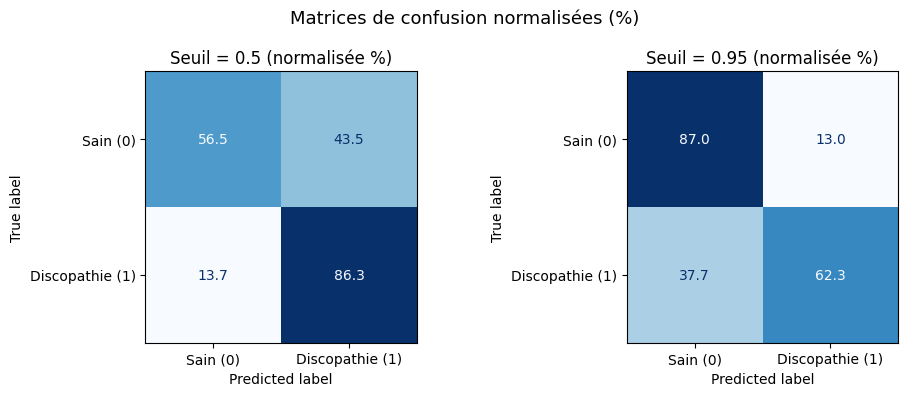

✅ Sauvegardé : /content/drive/MyDrive/spin_mri/confusion_matrix_normalized.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_cm_percent(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    cm_norm = cm / cm.sum(axis=1, keepdims=True) * 100
    disp = ConfusionMatrixDisplay(
        confusion_matrix=np.round(cm_norm, 1),
        display_labels=["Sain (0)", "Discopathie (1)"]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".1f")
    ax.set_title(title)

fig, axes = plt.subplots(1,2, figsize=(10,4))

plot_cm_percent(ys, (ps>=0.5).astype(int), axes[0], "Seuil = 0.5 (normalisée %)")
plot_cm_percent(ys, (ps>=0.95).astype(int), axes[1], "Seuil = 0.95 (normalisée %)")

plt.suptitle("Matrices de confusion normalisées (%)", fontsize=13)
plt.tight_layout()
plt.show()

out_path = "/content/drive/MyDrive/spin_mri/confusion_matrix_normalized.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print("✅ Sauvegardé :", out_path)


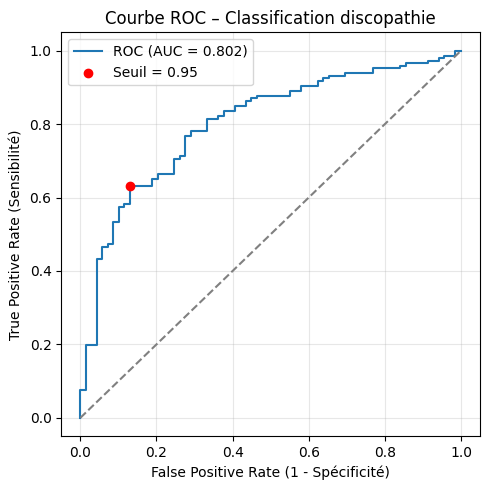

✅ ROC sauvegardée : /content/drive/MyDrive/spin_mri/roc_curve_cls.png


<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thr = roc_curve(ys, ps)
roc_auc = auc(fpr, tpr)

# trouver le point correspondant au seuil 0.95
thr_target = 0.95
idx_thr = np.argmin(np.abs(thr - thr_target))

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.scatter(fpr[idx_thr], tpr[idx_thr], color="red", zorder=3,
            label=f"Seuil = {thr_target}")
plt.plot([0,1],[0,1],'--', color='gray')

plt.xlabel("False Positive Rate (1 - Spécificité)")
plt.ylabel("True Positive Rate (Sensibilité)")
plt.title("Courbe ROC – Classification discopathie")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

out_path = "/content/drive/MyDrive/spin_mri/roc_curve_cls.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("✅ ROC sauvegardée :", out_path)


In [ ]:
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, f1_score

# df_val doit contenir Patient + label_bin
df_eval = df_val.copy().reset_index(drop=True)
df_eval["prob"] = ps

# agrégation patient
pat_eval = df_eval.groupby("Patient").agg(
    gt=("label_bin","max"),
    prob=("prob","max")
).reset_index()

pred_pat = (pat_eval["prob"] >= 0.95).astype(int)

bacc_pat = balanced_accuracy_score(pat_eval["gt"], pred_pat)
f1_pat = f1_score(pat_eval["gt"], pred_pat)

print("Patient-level BAcc:", bacc_pat)
print("Patient-level F1  :", f1_pat)


Patient-level BAcc: 0.9512195121951219
Patient-level F1  : 0.9487179487179487


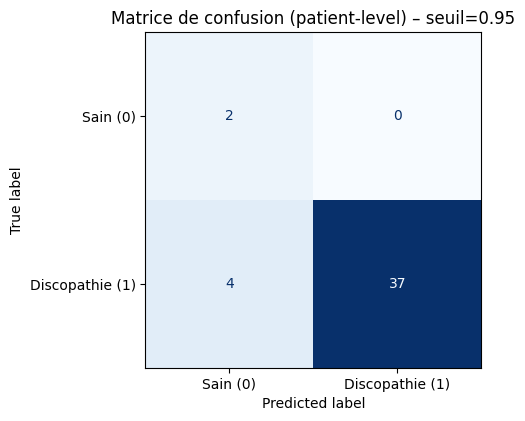

✅ Sauvegardée : /content/drive/MyDrive/spin_mri/confusion_matrix_patient_level.png


In [ ]:
#Matrice de confusion patient-level (graphique + sauvegarde)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

thr = 0.95  # seuil optimisé

# pat_eval doit exister (créé dans ta cellule patient-level)
# colonnes attendues: ["Patient", "gt", "prob"]
y_true_pat = pat_eval["gt"].values.astype(int)
y_prob_pat = pat_eval["prob"].values.astype(float)
y_pred_pat = (y_prob_pat >= thr).astype(int)

cm_pat = confusion_matrix(y_true_pat, y_pred_pat, labels=[0,1])

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pat,
    display_labels=["Sain (0)", "Discopathie (1)"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matrice de confusion (patient-level) – seuil={thr}")

plt.tight_layout()
plt.show()

out_path = "/content/drive/MyDrive/spin_mri/confusion_matrix_patient_level.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print("✅ Sauvegardée :", out_path)
